# Data Context

This analysis covers two datasets. The first is LUND-PROBE (Rogowski et al., 2025), which will be the public benchmark containing 432 prostate MRgRT patients from Skåne University Hospital, 
Lund, Sweden. Each patient folder contains a synthetic CT (sCT) image, an MRI (T2-Weighted), interpolated and original dose distributions, and segmentation masks for nine structures: CTV, PTV, Bladder, Rectum, FemoralHead_L, FemoralHead_R, PenileBulb, Genitalia, and BODY. The sCT serves as the primary model input because dose calculation depends on tissue density, which MR alone does not encode. Files are sorted in NIfTI format (.nii.gz) and organised per patient under a basePart directory with 432 patients and an extendedPart with an additional 35 annotated cases. LUND-PROBE is used as a reproducible public benchmark for controlled model comparision.

The second dataset is a private pancreatic MRgRT cohort from Amsterdam UMC. Initial inspection reveals per-fraction MR volumes in NIfTI format across approximately 74 training and 27 evaluation patients, with raw DICOM source data including structure sets and dose distributions available separately. Full characterisation of this cohort is pending confirmation of the dose and structure data format with the clinical supervisor (see Section 5 for the placeholder analysis).

In [4]:
# Standard library
import os
import json

# Third-party: data and visualisation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Medical imaging
import nibabel as nib
from pathlib import Path

# ----------------------------------------------------------------------
# Dataset paths 
# BASE_PATH points to the 432-patient basePart on the network drive.
# The metadata CSV and missing structures JSON sit one level up.
# ----------------------------------------------------------------------
BASE_PATH = Path(r"\\vumc.nl\Onderzoek\s4e-gpfs2\rath-research-01\Research\Research_Kidney_AI_OB_ABR_MP_NGA_Joris\NIKA\LUnd_dataset\lund-probe\lund-probe\basePart")

METADATA_CSV = BASE_PATH.parent / "patGeometryInformation_basePart.csv"
MISSING_JSON = BASE_PATH.parent / "missingStructures_basePart.json"

# Collect patient directories in sorted order for reproducibility
patient_dirs = sorted([d for d in BASE_PATH.iterdir() if d.is_dir()])

print(f"Patients found: {len(patient_dirs)}")
print(f"First patient: {patient_dirs[0].name if patient_dirs else 'None'}")
print(f"Last: {patient_dirs[-1].name if patient_dirs else 'None'}")

Patients found: 432
First patient: newAcq_01d2150e9b50efa1
Last: oldAcq_fffac611ac446b6f


In [5]:
# Summary table comparing key dataset properties side by side.
# Pancreatic cohort values marked as TBC (to be confirmed) where the
# data format has not yet been verified with the clinical supervisor.

summary_table = pd.DataFrame({
    "Property": [
        "Disease site",
        "Treatment modality",
        "Total patients",
        "Training / evaluation split",
        "Image format",
        "Primary input modality",
        "Dose format",
        "Structure masks",
        "Fractions per patient",
        "Image dimensions (approx.)",
        "In-plane voxel spacing",
        "Slice thickness",
        "Data availability",
    ],
    "LUND-PROBE": [
        "Prostate",
        "MR-guided radiotherapy (SBRT)",
        "432 (basePart)",
        "Not pre-split (patient-level split applied)",
        "NIfTI (.nii.gz)",
        "Synthetic CT (sCT)",
        "Interpolated onto sCT grid",
        "9 structures per patient",
        "Single fraction per folder",
        "~756 × 1024 × 88 (variable)",
        "0.4375–0.4688 mm",
        "2.5 mm",
        "Public",
    ],
    "AUMC Pancreatic": [
        "Pancreas",
        "MR-guided radiotherapy (SBRT)",
        "~101 (74 train + 27 eval)",
        "Pre-split into Training-nifti / Evaluation-nifti",
        "NIfTI (.nii.gz) + raw DICOM",
        "MR image (TBC)",
        "TBC — DICOM dose files present in source",
        "TBC — DICOM RTSS present in source",
        "Multiple fractions per patient (0–5+)",
        "266 × 266 × 144",
        "1.50 mm",
        "3.0 mm",
        "Private (Amsterdam UMC)",
    ]
}).set_index("Property")

summary_table

,LUND-PROBE,AUMC Pancreatic
Property,,
Disease site,Prostate,Pancreas
Treatment modality,MR-guided radiotherapy (SBRT),MR-guided radiotherapy (SBRT)
Total patients,432 (basePart),~101 (74 train + 27 eval)
Training / evaluation split,Not pre-split (patient-level split applied),Pre-split into Training-nifti / Evaluation-nifti
Image format,NIfTI (.nii.gz),NIfTI (.nii.gz) + raw DICOM
Primary input modality,Synthetic CT (sCT),MR image (TBC)
Dose format,Interpolated onto sCT grid,TBC — DICOM dose files present in source
Structure masks,9 structures per patient,TBC — DICOM RTSS present in source
Fractions per patient,Single fraction per folder,Multiple fractions per patient (0–5+)


## LUND-PROBE Analysis

The following analyses characterise the LUND-PROBE dataset across five levels: dataset inventory, image geometry, intensity and acquisition properties, dose distribution, and structure volumes. Together these observations inform the preprocessing decisions made in the subsequent pipeline.

### 3.1 Dataset Inventory

First we confirm whether all expected patients are present and that the dataset's complete metadata, the geometry CSV and the missing structures JSON, are accessible and interpretable. Here the corpus-level picture is established before any image-level is loaded.The geometry CSV contains per-patient image dimensions, voxel spacing, and dose range, while the missing structures JSON flags any patients where segmentations are absent. Together these give a dataset-wide view of the cohort without the overhead of opening a single image file.

In [6]:
# Load the per-patient geometry metadata provided with LUND-PROBE.
# This tells is image dimensions, voxelspacing, intesnity statistics,
# and structure volumes for every patient, without loading a single image.

df = pd.read_csv(METADATA_CSV, sep=";")

print(f"Metadata shape: {df.shape}")  # (rows, columns) — expect ~432 rows
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nFirst two rows:")
df.head(2)

Metadata shape: (432, 9)

Column names:
['patient', 'sCTMatrixSizeOrig', 'sCTVoxelSizeOrig (mm)', 'mriMatrixSize', 'mriVoxelSize (mm)', 'doseMatrixSizeOrig', 'doseVoxelSizeOrig', 'doseMin (Gy)', 'doseMax (Gy) ']

First two rows:


,patient,sCTMatrixSizeOrig,sCTVoxelSizeOrig (mm),mriMatrixSize,mriVoxelSize (mm),doseMatrixSizeOrig,doseVoxelSizeOrig,doseMin (Gy),doseMax (Gy)
0,oldAcq_ca05ccf044225231,"(756, 1024, 88)","(0.4375, 0.4375, 2.5)","(1024, 1024, 88)","(0.4375, 0.4375, 2.5)","(108, 162, 88)","(2.5, 2.5, 2.5)",0.0,44.30
1,oldAcq_0cbde6c35fb03c23,"(756, 1024, 88)","(0.4375, 0.4375, 2.5)","(1024, 1024, 88)","(0.4375, 0.4375, 2.5)","(116, 174, 88)","(2.5, 2.5, 2.5)",0.0,44.19


to be checked in the preprocessing stage:
- dimensions sct and mri should be the same
    -> now: sct and mri have different in-plane sizes (756 vs 1024). sCT doesn't cover the full field of view of the MR. sCT often crops body the body region. 
    -> input sizes need to be consistent

for training:
- use the dose_interpolated.mii.gz (resampled version)

### 3.2 Image Geometry

With 432 patients confirmed, we examine whether image geometry is consistent across 
the cohort. Inconsistent voxel spacing or matrix size would require a resampling 
step during preprocessing to bring all volumes onto a common spatial grid before 
model training. The metadata CSV allows us to answer this question across all 432 
patients at once without loading any image data.

In [7]:
# Consitensy check of image geometry across all 432 patients. 
# For a well-curated public dataset uniformity is expected, but important to verify. 
# Inconsitency in spacing or dimesnions would require per-patient resampling during preprocessing.

print("=== sCT Matrix Size (unique values) ===")
print(df["sCTMatrixSizeOrig"].value_counts())

print("\n=== sCT Voxel Size (unique values) ===")
print(df["sCTVoxelSizeOrig (mm)"].value_counts())

print("\n=== MRI Matrix Size (unique values) ===")
print(df["mriMatrixSize"].value_counts())

print("\n=== Dose Range across patients ===")
print(f"Min dose (Gy): {df['doseMin (Gy)'].describe()}")
print(f"\nMax dose (Gy):\n{df['doseMax (Gy) '].describe()}")

=== sCT Matrix Size (unique values) ===
sCTMatrixSizeOrig
(756, 1024, 88)     99
(756, 1021, 88)     47
(756, 1022, 88)     45
(682, 1024, 88)     43
(756, 1020, 88)     37
(756, 1023, 88)     33
(682, 1023, 88)     21
(716, 1024, 88)     15
(682, 1022, 88)     13
(756, 1019, 88)     10
(682, 1021, 88)      8
(716, 1023, 88)      6
(682, 1020, 88)      5
(682, 1019, 88)      4
(716, 1021, 88)      4
(716, 1022, 88)      3
(716, 1020, 88)      3
(682, 1018, 88)      3
(682, 1016, 88)      2
(682, 1012, 88)      2
(682, 1017, 88)      2
(756, 1024, 79)      2
(756, 1022, 85)      2
(756, 1019, 85)      1
(756, 1011, 88)      1
(716, 1019, 88)      1
(682, 1009, 88)      1
(756, 1022, 78)      1
(682, 1015, 88)      1
(756, 1021, 85)      1
(756, 1021, 77)      1
(756, 1019, 79)      1
(682, 993, 88)       1
(858, 1009, 88)      1
(756, 1022, 87)      1
(682, 949, 88)       1
(682, 1004, 88)      1
(858, 1024, 88)      1
(756, 1007, 88)      1
(756, 1019, 80)      1
(756, 1020, 81)      1

### Observations: Image Geometry and Dose Range - Findings important for preprocessing:

- sCT matrix size: significant variation,  46 unique dimension combinations found.
    - Z dimension (no. of slices) is almost always 88. but some with 79, 85, 77, 85, 104 slices = outliers.
    - X dimension (field of view reflecting different body sizes) varies between 3 main values: 682, 716, and 756 (latter most common, approx. 60%).
    - Y dimension small fluctuations around 1024 due to minor differences in how the scan was reconstructed.
> Needs resampling and cropping/padding strategy.

- sCT voxel spacing: three main groups, majority (310/ 432 patients) have 0.4375mm in-plane spacing. others; 0.4688mm.
    -  Z spacing is consistently 2.5mm across everyone.
> Needs resampling to a common voxel spacing, most likely 0.4375mm in-plane since that's the most prevalent. 

- MRI matrix size: uniform, no need for preprocessing.
    -  1024×1024×88.
> Reference for sCT to match it?

- Dose range: 
    - min dose = 0.0 (expected), voxels outside treatment field receive no dose.
    - max dose = 44.25 Gy, STD = 0.43 Gy, dose scales consistent across patients.
    - outliers: 38.32 Gy and 45.89 Gy.

In [8]:
# Loading the missing structures JSON to understand which patient have missing segmentations.
# Patients with missing crittical structures (e.g. CTV, PTV) may need to be excluded from training,
# So we need to now how many there are and which structures are missing.

with open(MISSING_JSON, "r") as f:
    missing = json.load(f)

print(f"Patients with at least one missing structure: {len(missing)}")
print(f"\nFirst entry as example:")

# Show just the first entry so we understand the data format
first_key = list(missing.keys())[0]
print(f"  Patient: {first_key}")
print(f"  Missing: {missing[first_key]}")

Patients with at least one missing structure: 48

First entry as example:
  Patient: oldAcq_522d43d20ac30f75
  Missing: ['mask_PenileBulb.nii.gz']


In [9]:
# Summarise which structures are missing and how frequently.
# This tells us whether missing data affects critical structures (CTV, PTV)
# or only secondary organs at risk — which determines whether affected
# patients need to be excluded from training.
from collections import Counter

# Flatten all missing structure names across all affected patients
all_missing = []
for patient_id, structures in missing.items():
    all_missing.extend(structures)

missing_counts = Counter(all_missing)

print(f"Missing structure frequencies across {len(missing)} patients:\n")
for structure, count in missing_counts.most_common():
    print(f"  {structure:<35s} missing in {count} patient(s)")

Missing structure frequencies across 48 patients:

  mask_PenileBulb.nii.gz              missing in 29 patient(s)
  mask_Genitalia.nii.gz               missing in 24 patient(s)


### Missing structure findings.

- Only 2 secondary OARs are missing: PenileBulb and Genitalia.
- No PTV or CTV are missing.
> For model training to learn dose mapping it requires the PTV and CTV, and since they're not missing the data is of good quality for training.

Some patients mis both the penilebulb and genitalia, possibly because of the contouring protocol varied across the years the data was collected.

> All 432 patients will be included in training. for structure masks encoding penilebulb and genitalia will be optional of when those structures are missing value will be 0s for that channel (mention in methodology).

In [10]:
# Corpus-level summary.
# This consolidates the key dataset properties into one readable table,
# which can be referenced directly in the thesis methodology section.

summary = {
    "Total patients": len(patient_dirs),
    "Patients with missing structures": len(missing),
    "Critical structures missing (CTV/PTV)": 0,
    "Unique sCT in-plane spacings": df["sCTVoxelSizeOrig (mm)"].nunique(),
    "Dominant sCT spacing (most common)": df["sCTVoxelSizeOrig (mm)"].value_counts().index[0],
    "MRI matrix size (all patients)": df["mriMatrixSize"].unique()[0],
    "Mean max dose (Gy)": round(df["doseMax (Gy) "].mean(), 2),
    "Std max dose (Gy)": round(df["doseMax (Gy) "].std(), 2),
}

summary_df = pd.DataFrame.from_dict(summary, orient="index", columns=["Value"])
print(summary_df.to_string())

                                                       Value
Total patients                                           432
Patients with missing structures                          48
Critical structures missing (CTV/PTV)                      0
Unique sCT in-plane spacings                               5
Dominant sCT spacing (most common)     (0.4375, 0.4375, 2.5)
MRI matrix size (all patients)              (1024, 1024, 88)
Mean max dose (Gy)                                     44.25
Std max dose (Gy)                                       0.43


### 3.3 Single Patient Inspection and Intensity Analysis

Before analysing the full dataset, we load one patient to verify the file structure, inspect array shapes and intensity ranges, and visualise the three key volumes: the sCT input, the interpolated dose (prediction target), and an example structure mask. This grounds the corpus-level statistics in something concrete and confirms the 
loading pipeline works as expected.

We then examine whether the two acquisition groups visible in the patient ID prefixes, oldAcq and newAcq, differ systematically in geometry or intensity. Such a difference would affect how the dataset should be split for training and evaluation, since a model trained predominantly on one acquisition type may not generalise well 
to the other.

In [11]:
# Load one patient for detailed inspection.
# We pick one patientin sorted order, not random, 
# to ensure this is reproducable and consistent across runs.
patient = patient_dirs[0]
sct_dir = patient / "sCT"

print(f"Inspecting patient: {patient.name}")

# Load sCT image 
sct_img  = nib.load(sct_dir / "image.nii.gz")
sct_data = sct_img.get_fdata()

# Load interpolated dose (our prediction target)
dose_img  = nib.load(sct_dir / "dose_interpolated.nii.gz")
dose_data = dose_img.get_fdata()

# Load one structure mask: the CTV (treatment target)
ctv_img  = nib.load(sct_dir / "mask_CTVT_427.nii.gz")
ctv_data = ctv_img.get_fdata()

# Print shape and spacing for each volume
for name, img, data in [
    ("sCT",      sct_img,  sct_data),
    ("Dose",     dose_img, dose_data),
    ("CTV mask", ctv_img,  ctv_data),
]:
    zooms = img.header.get_zooms()
    print(f"\n{name}")
    print(f"  Shape:   {data.shape}")
    print(f"  Spacing: {zooms[0]:.4f} x {zooms[1]:.4f} x {zooms[2]:.4f} mm")
    print(f"  Range:   [{data.min():.2f}, {data.max():.2f}]")

Inspecting patient: newAcq_01d2150e9b50efa1

sCT
  Shape:   (993, 682, 88)
  Spacing: 0.4688 x 0.4688 x 2.5000 mm
  Range:   [-1000.00, 4143.00]

Dose
  Shape:   (993, 682, 88)
  Spacing: 0.4688 x 0.4688 x 2.5000 mm
  Range:   [0.00, 43.79]

CTV mask
  Shape:   (993, 682, 88)
  Spacing: 0.4688 x 0.4688 x 2.5000 mm
  Range:   [0.00, 1.00]


### Notes and observations:

The sCT range of -1000 to 4143 is in Hounsfield Units (HU), the standard scale for CT density. In this scale, -1000 HU is air, 0 HU is water, and bone is typically above 400 HU. The value 4143 is unusually high,  normal bone tops out around 1000-1500 HU, so this patient likely has a hip prosthesis or some dense implant. Worth keeping in mind as a potential outlier case.



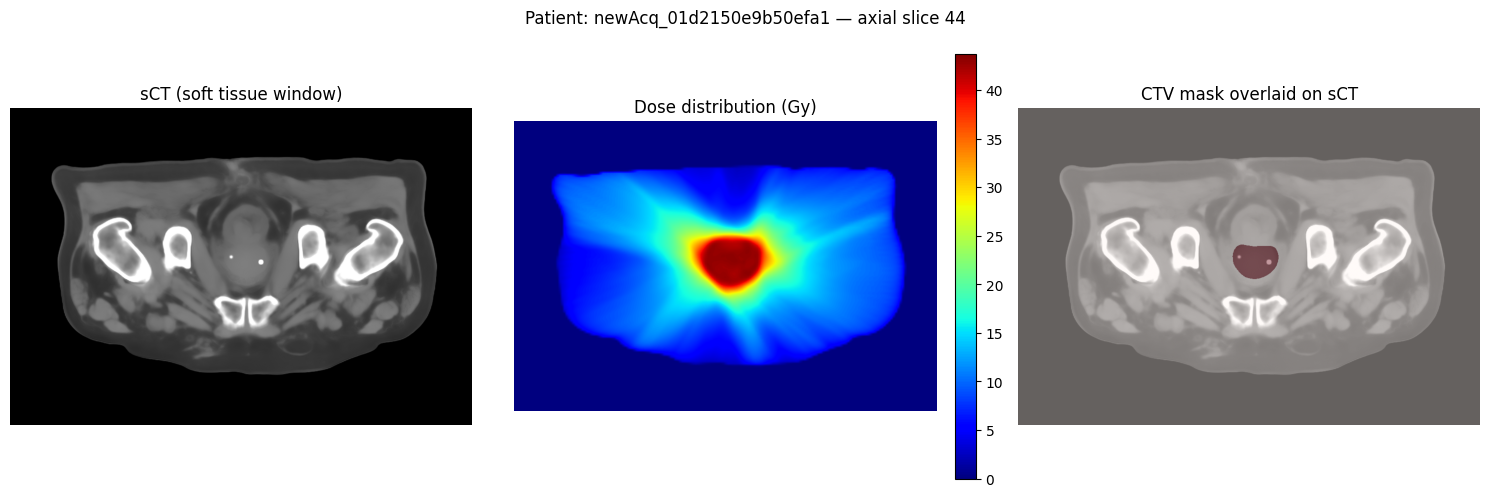

In [12]:
# Visualise the central axial slice for sCT, dose, and CTV mask.
# The central slice is often the most informative for visual inspection 
# as it typically contains the largest cross-section of the target and OARs,
# and reliably falss within the anatomy for all patients, 
# unlike the top or bottom slices which may be mostly empty air.
z_mid = sct_data.shape[2] // 2  # central slice index along Z axis

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# sCT: windowed to soft tissue range for better visual contrast.
# Full HU range (-1000 to 4000) would wash out soft tissue detail.
axes[0].imshow(sct_data[:, :, z_mid].T, cmap="gray",
               vmin=-200, vmax=300, origin="lower")
axes[0].set_title("sCT (soft tissue window)")
axes[0].axis("off")

# Dose: full range so we can see the dose gradient clearly
im = axes[1].imshow(dose_data[:, :, z_mid].T, cmap="jet",
                    vmin=0, vmax=dose_data.max(), origin="lower")
axes[1].set_title("Dose distribution (Gy)")
axes[1].axis("off")
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

# CTV mask overlaid on sCT so we can see where the target sits
axes[2].imshow(sct_data[:, :, z_mid].T, cmap="gray",
               vmin=-200, vmax=300, origin="lower")
axes[2].imshow(ctv_data[:, :, z_mid].T, cmap="Reds",
               alpha=0.4, origin="lower")
axes[2].set_title("CTV mask overlaid on sCT")
axes[2].axis("off")

fig.suptitle(f"Patient: {patient.name} — axial slice {z_mid}", fontsize=12)
plt.tight_layout()
plt.show()

### Notes and observations: single patient visuals
In the sCT you can see the pelvic anatomy: the two bright white structures on the left and right are the femoral heads (hip bones), and the central soft tissue region is the pelvis where the prostate sits. The two small bright dots near the centre are likely fiducial markers, tiny implanted seeds used to track the prostate position during treatment.

The dose distribution: a hot red core concentrated where the CTV is, surrounded by a smooth gradient that falls off toward the edges. This gradient shape, called a dose falloff is clinically intentional. The treatment aims to deliver full dose to the target while the dose to surrounding tissue drops as steeply as possible to spare OARs.

The CTV overlay confirms the red core in the dose image corresponds to the delineated target volume.

In [14]:
# Investigate whether the oldAcq and newAcq patient groups differ systematically.
# The prefix in each patient ID reflects the acquisition batch — likely a scanner
# upgrade or protocol change. If the two groups differ in geometry or dose range,
# the train/test split should be stratified by acquisition group to avoid the model
# learning batch effects rather than anatomy-to-dose mappings.

# Extract acquisition group from patient ID
df["acq_group"] = df["patient"].apply(
    lambda x: "oldAcq" if x.startswith("oldAcq") else "newAcq"
)

print("Patient counts per acquisition group:")
print(df["acq_group"].value_counts())
print()

# Compare dose range between groups
print("Max dose (Gy) by acquisition group:")
print(df.groupby("acq_group")["doseMax (Gy) "].describe().round(2))

Patient counts per acquisition group:
acq_group
oldAcq    323
newAcq    109
Name: count, dtype: int64

Max dose (Gy) by acquisition group:
           count   mean   std    min    25%    50%    75%    max
acq_group                                                       
newAcq     109.0  44.26  0.34  43.31  44.01  44.21  44.53  45.17
oldAcq     323.0  44.25  0.46  38.32  44.06  44.23  44.48  45.89


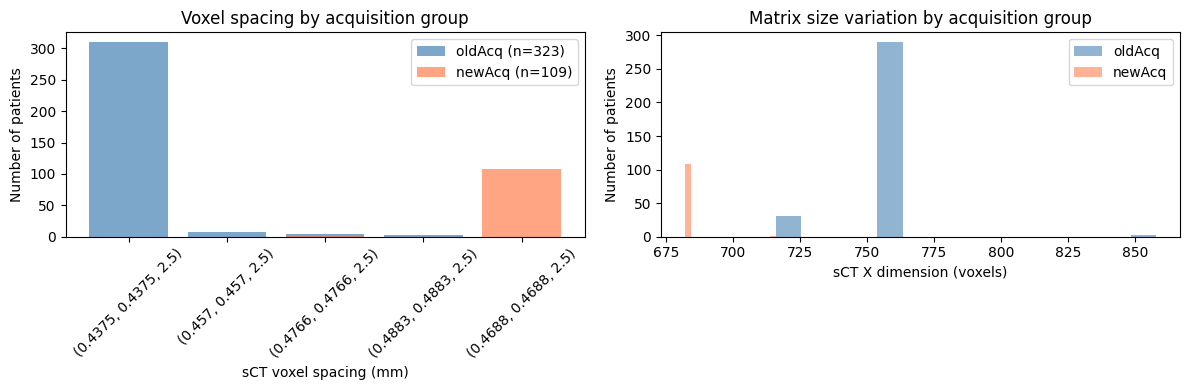

sCT voxel spacing counts by acquisition group:
sCTVoxelSizeOrig (mm)  (0.4375, 0.4375, 2.5)  (0.457, 0.457, 2.5)  \
acq_group                                                           
newAcq                                     0                    0   
oldAcq                                   310                    7   

sCTVoxelSizeOrig (mm)  (0.4688, 0.4688, 2.5)  (0.4766, 0.4766, 2.5)  \
acq_group                                                             
newAcq                                   108                      1   
oldAcq                                     0                      4   

sCTVoxelSizeOrig (mm)  (0.4883, 0.4883, 2.5)  
acq_group                                     
newAcq                                     0  
oldAcq                                     2  


In [ ]:
# Compare sCT voxel spacing distribution between acquisition groups.
# Spacing variation is more likely to reflect scanner protocol changes rather than dose variation,
# so this is a useful proxy for identifying batch effects that could confound the model.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Spacing distribution between groups
for group, colour in [("oldAcq", "steelblue"), ("newAcq", "coral")]:
    subset = df[df["acq_group"] == group]["sCTVoxelSizeOrig (mm)"]
    counts = subset.value_counts().sort_index()
    label = f"{group} (n={len(subset)})"
    axes[0].bar(
        [str(s) for s in counts.index],
        counts.values,
        alpha=0.7, label=label, color=colour
    )

axes[0].set_xlabel("sCT voxel spacing (mm)")
axes[0].set_ylabel("Number of patients")
axes[0].set_title("Voxel spacing by acquisition group")
axes[0].legend()
axes[0].tick_params(axis="x", rotation=45)

# X dimension distribution per group, proxy for field of view differences
x_dims = df["sCTMatrixSizeOrig"].apply(
    lambda s: int(s.strip("()").split(",")[0])
)
df["sct_x_dim"] = x_dims

for group, colour in [("oldAcq", "steelblue"), ("newAcq", "coral")]:
    subset = df[df["acq_group"] == group]["sct_x_dim"]
    axes[1].hist(subset, bins=15, alpha=0.6, label=group, color=colour)

axes[1].set_xlabel("sCT X dimension (voxels)")
axes[1].set_ylabel("Number of patients")
axes[1].set_title("Matrix size variation by acquisition group")
axes[1].legend()

plt.tight_layout()
plt.show()

# Summarise spacing by group in a table
print("sCT voxel spacing counts by acquisition group:")
print(df.groupby(["acq_group", "sCTVoxelSizeOrig (mm)"]).size().unstack(fill_value=0))

### Notes/observations:
The acquisition groups show a near-complete separation in voxel spacing: all 109 newAcq patients use 0.4688mm in-plane spacing, while the large majority of oldAcq patients (310 of 323) use 0.4375mm spacing. A small number of oldAcq patients (13 of 323) use other spacings, likely reflecting individual scan exceptions rather than a systematic protocol difference. The matrix size variation follows the same pattern, with newAcq patients clustering at a smaller X dimension (~682 voxels) compared to oldAcq (~756 voxels). These findings indicate that the two groups represent geometrically distinct populations. Patient-level train/test splitting should therefore be stratified by acquisition group to prevent distribution shift between training and evaluation sets.

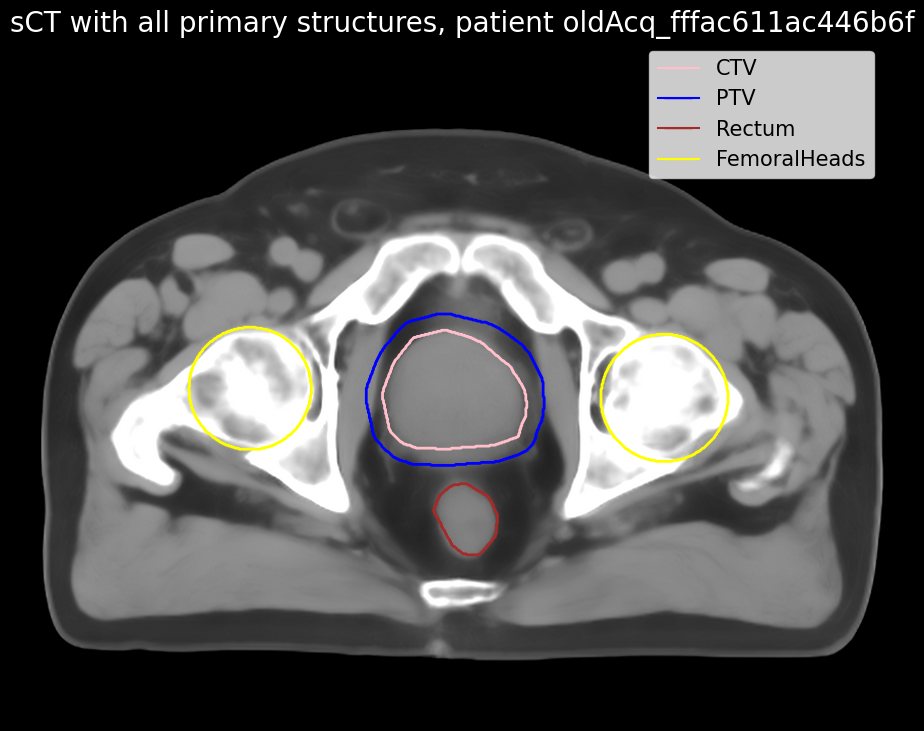

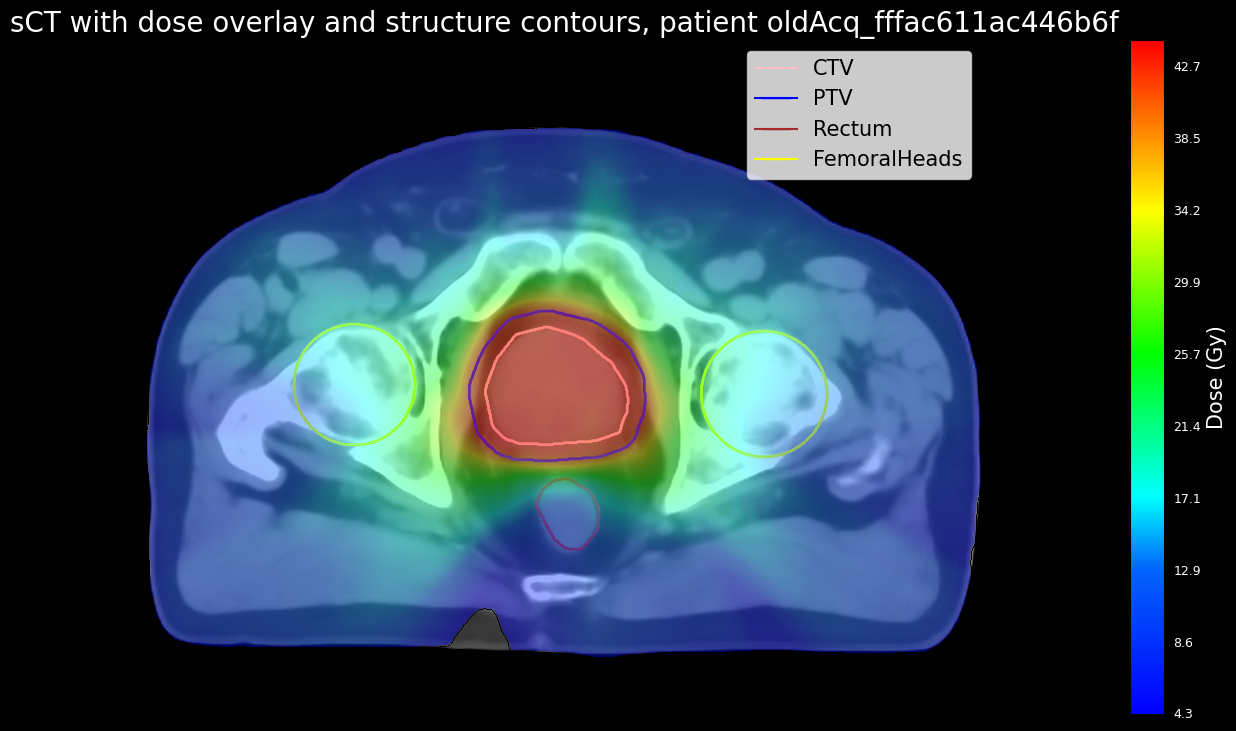

In [34]:
# Rich multi-structure visualisation using the official LUND-PROBE plotting module.
# This uses SimpleITK for loading because ioPlotFunctions expects (Z, Y, X) array
# ordering, which is what SimpleITK's GetArrayFromImage returns, the opposite of
# nibabel's convention. Our nibabel-based loading cells are unaffected.

import SimpleITK as sitk
from ioPlotFunctions import plotFunctions

pf = plotFunctions()

# Load all structures for the same patient we've been inspecting
sct_dir_str = str(patient / "sCT")

sct_sitk   = sitk.ReadImage(str(patient / "sCT" / "image.nii.gz"))
dose_sitk  = sitk.ReadImage(str(patient / "sCT" / "dose_interpolated.nii.gz"))
ctv_sitk   = sitk.ReadImage(str(patient / "sCT" / "mask_CTVT_427.nii.gz"))
ptv_sitk   = sitk.ReadImage(str(patient / "sCT" / "mask_PTVT_427.nii.gz"))
rect_sitk  = sitk.ReadImage(str(patient / "sCT" / "mask_Rectum.nii.gz"))
blad_sitk  = sitk.ReadImage(str(patient / "sCT" / "mask_Bladder.nii.gz"))
fhl_sitk   = sitk.ReadImage(str(patient / "sCT" / "mask_FemoralHead_L.nii.gz"))
fhr_sitk   = sitk.ReadImage(str(patient / "sCT" / "mask_FemoralHead_R.nii.gz"))

sct_arr  = sitk.GetArrayFromImage(sct_sitk)
dose_arr = sitk.GetArrayFromImage(dose_sitk)
ctv_arr  = sitk.GetArrayFromImage(ctv_sitk)
ptv_arr  = sitk.GetArrayFromImage(ptv_sitk)
rect_arr = sitk.GetArrayFromImage(rect_sitk)
blad_arr = sitk.GetArrayFromImage(blad_sitk)
fhl_arr  = sitk.GetArrayFromImage(fhl_sitk)
fhr_arr  = sitk.GetArrayFromImage(fhr_sitk)

# Plot sCT with all primary structures overlaid, no dose map.
# zoomingShape=[50, 960, 800, 200] crops to the pelvic region, matching the
# visualisation convention used in the LUND-PROBE publication.
pf.plotData(
    sct_arr,
    structCTVArray=ctv_arr,
    structRectumArray=rect_arr,
    structPTVArray=ptv_arr,
    structFemoralHeadLArray=fhl_arr,
    structFemoralHeadRArray=fhr_arr,
    showDosemap=False,
    showStructArrays=True,
    Title=f"sCT with all primary structures, patient {patient.name}",
    showLegend=True,
    ct=True,
    zooming=True,
    zoomingShape=[100, 930, 720, 50]
)

# Plot sCT with dose overlay and structure contours, the most clinically
# informative single view, showing where dose is delivered relative to anatomy.
pf.plotData(
    sct_arr,
    doseMapArray=dose_arr,
    structCTVArray=ctv_arr,
    structRectumArray=rect_arr,
    structPTVArray=ptv_arr,
    structFemoralHeadLArray=fhl_arr,
    structFemoralHeadRArray=fhr_arr,
    showDosemap=True,
    showStructArrays=True,
    Title=f"sCT with dose overlay and structure contours, patient {patient.name}",
    showLegend=True,
    ct=True,
    zooming=True,
    zoomingShape=[100, 930, 720, 50]
)

In [22]:
# Record the acquisition group composition for use during train/test splitting. 

acq_counts = df["acq_group"].value_counts()
acq_spacing = df.groupby("acq_group")["sCTVoxelSizeOrig (mm)"].value_counts()

print("Acquisition group summary:")
print(f"  oldAcq: {acq_counts['oldAcq']} patients "
      f"({acq_counts['oldAcq']/len(df):.1%} of cohort)")
print(f"  newAcq: {acq_counts['newAcq']} patients "
      f"({acq_counts['newAcq']/len(df):.1%} of cohort)")
print(f"\nSpacing is largely separated between groups: "
      f"oldAcq → predominantly 0.4375mm (310/323 patients), "
      f"newAcq → exclusively 0.4688mm (108/109 patients)")
print(f"\nAction: apply stratified splitting by acquisition group "
      f"when constructing train/val/test splits.")

Acquisition group summary:
  oldAcq: 323 patients (74.8% of cohort)
  newAcq: 109 patients (25.2% of cohort)

Spacing is largely separated between groups: oldAcq → predominantly 0.4375mm (310/323 patients), newAcq → exclusively 0.4688mm (108/109 patients)

Action: apply stratified splitting by acquisition group when constructing train/val/test splits.


In [ ]:
# Dataset-wide sCT intensity analysis.
# For each patient we compute the mean, 2nd percentile, and 98th percentile
# of non-zero HU values, and the absolute maximum. Loading the full array
# and immediately summarising avoids memory accumulation across 432 patients.
# We use percentiles rather than min/max for the distribution summary because
# a single extreme voxel (e.g. a metal implant) would otherwise dominate the range.

intensity_records = []

for patient_dir in tqdm(patient_dirs, desc="Computing sCT intensity statistics"):
    sct_path = patient_dir / "sCT" / "image.nii.gz"
    data = nib.load(sct_path).get_fdata().flatten()

    # Restrict to non-air voxels — air is -1000 HU and dominates the distribution
    # if included, since most of the volume outside the patient body is air.
    tissue = data[data > -500]

    intensity_records.append({
        "patient":    patient_dir.name,
        "acq_group":  "oldAcq" if patient_dir.name.startswith("oldAcq") else "newAcq",
        "mean_hu":    tissue.mean(),
        "p2_hu":      np.percentile(tissue, 2),
        "p98_hu":     np.percentile(tissue, 98),
        "max_hu":     data.max(),
    })

intensity_df = pd.DataFrame(intensity_records)

print("sCT intensity statistics across 432 patients:")
print(intensity_df[["mean_hu", "p2_hu", "p98_hu", "max_hu"]].describe().round(1))

Computing sCT intensity statistics: 100%|██████████| 432/432 [28:30<00:00,  3.96s/it]

sCT intensity statistics across 432 patients:
       mean_hu  p2_hu  p98_hu  max_hu
count    432.0  432.0   432.0   432.0
mean      11.8 -111.0   451.1  4135.6
std       17.5    3.2    65.1     5.6
min      -31.4 -126.0   296.0  4111.0
25%       -0.3 -113.0   398.0  4132.0
50%       12.0 -111.0   450.0  4135.0
75%       25.1 -109.0   501.2  4139.0
max       58.6 -104.0   635.0  4183.0

Patients with max HU above 2000 (possible implant):
                patient acq_group  max_hu
newAcq_01d2150e9b50efa1    newAcq  4143.0
newAcq_01dc375e00d9c048    newAcq  4140.0
newAcq_045d65bfad81151e    newAcq  4133.0
newAcq_04f91c3d466ff88e    newAcq  4131.0
newAcq_0a5468e3fad3e7c5    newAcq  4144.0
newAcq_0f1b9b329830d5c5    newAcq  4139.0
newAcq_127034f8bf8effd8    newAcq  4134.0
newAcq_1633ac7696d0d30a    newAcq  4134.0
newAcq_1822dbce54d2268a    newAcq  4138.0
newAcq_1db097c32a34ce8f    newAcq  4133.0
newAcq_1fc114d92cf97123    newAcq  4131.0
newAcq_2093abb7119bcfdf    newAcq  4139.0
newAcq_23bc82

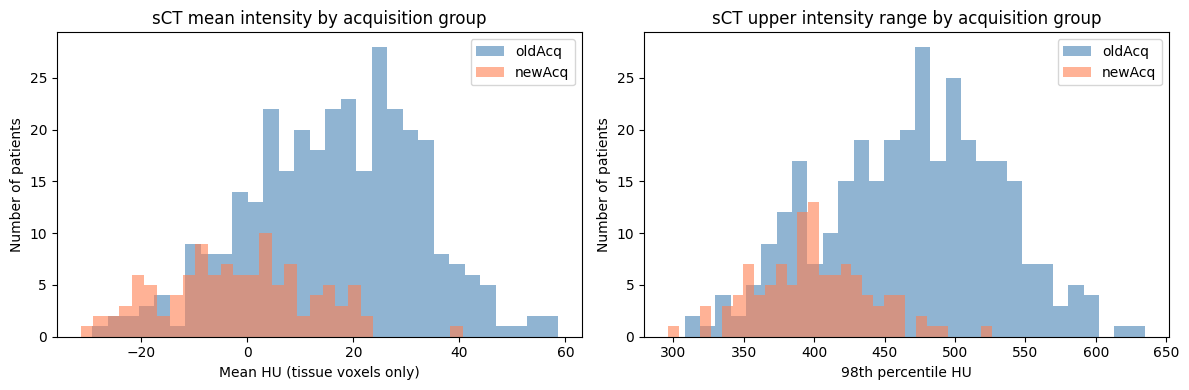

sCT intensity comparison by acquisition group:
          mean_hu                   p98_hu                    
             mean   std   min   max   mean   std    min    max
acq_group                                                     
newAcq       -1.9  13.8 -31.4  40.6  398.9  40.4  296.0  526.0
oldAcq       16.4  16.1 -29.2  58.6  468.7  62.3  308.0  635.0

Statistical outliers in mean HU (IQR method): 0 patients
No significant intensity outliers detected.


In [36]:
# Summarise intensity statistics by acquisition group.
# Mean HU and p98 HU are the informative measures, max HU is a sCT generation
# artefact (clipping at the 12-bit integer ceiling) and is not clinically meaningful.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Mean HU distribution by acquisition group
for group, colour in [("oldAcq", "steelblue"), ("newAcq", "coral")]:
    subset = intensity_df[intensity_df["acq_group"] == group]["mean_hu"]
    axes[0].hist(subset, bins=30, alpha=0.6, label=group, color=colour)
axes[0].set_xlabel("Mean HU (tissue voxels only)")
axes[0].set_ylabel("Number of patients")
axes[0].set_title("sCT mean intensity by acquisition group")
axes[0].legend()

# p98 HU distribution, proxy for upper bone density calibration
for group, colour in [("oldAcq", "steelblue"), ("newAcq", "coral")]:
    subset = intensity_df[intensity_df["acq_group"] == group]["p98_hu"]
    axes[1].hist(subset, bins=30, alpha=0.6, label=group, color=colour)
axes[1].set_xlabel("98th percentile HU")
axes[1].set_ylabel("Number of patients")
axes[1].set_title("sCT upper intensity range by acquisition group")
axes[1].legend()

plt.tight_layout()
plt.show()

# Concise group comparison table, this is what belongs in the EDA writeup
print("sCT intensity comparison by acquisition group:")
print(
    intensity_df.groupby("acq_group")[["mean_hu", "p98_hu"]]
    .agg(["mean", "std", "min", "max"])
    .round(1)
)

# Flag genuine statistical outliers using IQR method on mean HU,
# these are patients whose sCT calibration is meaningfully different
# from the cohort, not just patients with dense bone at the HU ceiling.
q1 = intensity_df["mean_hu"].quantile(0.25)
q3 = intensity_df["mean_hu"].quantile(0.75)
iqr = q3 - q1
outlier_mask = (
    (intensity_df["mean_hu"] < q1 - 1.5 * iqr) |
    (intensity_df["mean_hu"] > q3 + 1.5 * iqr)
)

print(f"\nStatistical outliers in mean HU (IQR method): "
      f"{outlier_mask.sum()} patients")
if outlier_mask.sum() > 0:
    print(intensity_df[outlier_mask][["patient", "acq_group", "mean_hu"]].to_string(index=False))
else:
    print("No significant intensity outliers detected.")

### Notes/observations:
The newAcq group has a mean HU of −1.9 compared to 16.4 for oldAcq, a difference of 18.3 HU. The 98th percentile HU differs more substantially: 398.9 HU for newAcq versus 468.7 HU for oldAcq, a gap of 69.8 HU. This difference in the upper intesity range is consistent with the coarser 0.4688mm in-plane voxel spacing of the newAcq group:Each voxel represents a small cube of physical space, and its recorded HU value is effectively an average of everything inside that cube. When voxels are larger, a single voxel near a bone boundary contains a mixture of dense bone and adjacent soft tissue, so its recorded value is pulled toward the middle rather than reflecting the true peak bone density. Smaller voxels can sit more precisely inside the bone itself, capturing its full density without dilution from neighbouring tissue. The effect is a consequence of resolution rather than a calibration difference between the two acquisition groups. No individual patients were found as intensity outliers using the IGR method, confirming that all patients fall within the expected intesity range for their group. The sCT intensity clipping ceiling visible in all patients at approximately 4135 HU reflects the synthetic CT generation algorithm rather than pathological anatomy such as metal implants. These findings indicate that a single shared normalisation strategy is appropriate for both acquisition groups, provided resampling to a common voxel spacing is applied first.

### 3.4 Dose Distribution

Dose volume is the prediction target for all three models. Here we inspect the statistical properties at the patient level and across the cohort.

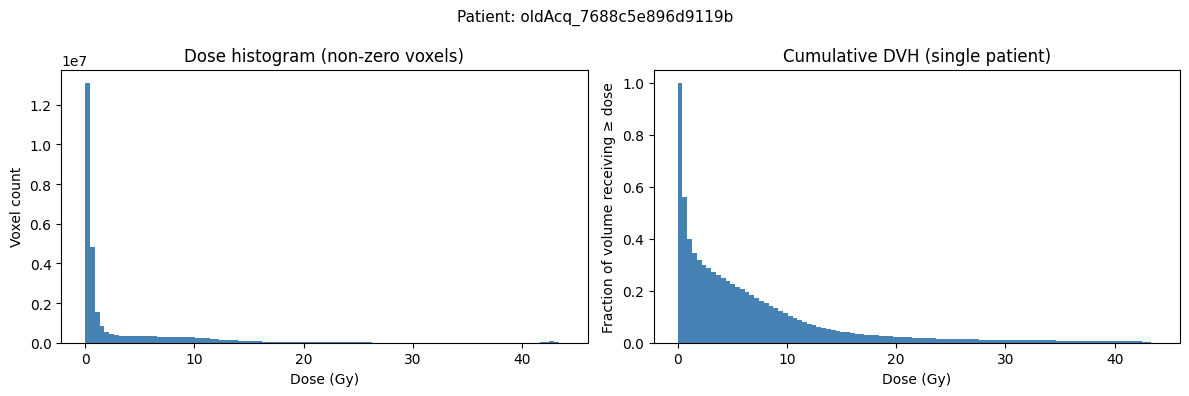

Non-zero voxel count: 29,851,349
Fraction of volume receiving full dose (>40 Gy): 0.6%


In [23]:
# Characterise the dose distribution shape for this patient.
# We look at the histogram of non-zero dose voxels — voxels receiving
# zero dose are outside the treatment field and would dominate the plot
# if included, obscuring the clinically relevant dose range.

dose_nonzero = dose_data[dose_data > 0].flatten()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of non-zero dose voxels
axes[0].hist(dose_nonzero, bins=100, color="steelblue", edgecolor="none")
axes[0].set_xlabel("Dose (Gy)")
axes[0].set_ylabel("Voxel count")
axes[0].set_title("Dose histogram (non-zero voxels)")

# Cumulative distribution - this is related to the DVH concept.
# A DVH (dose-volume histogram) is the standard clinical tool for
# evaluating radiotherapy plans, so understanding this shape matters
axes[1].hist(dose_nonzero, bins=100, cumulative=-1,
             density=True, color="steelblue", edgecolor="none")
axes[1].set_xlabel("Dose (Gy)")
axes[1].set_ylabel("Fraction of volume receiving ≥ dose")
axes[1].set_title("Cumulative DVH (single patient)")

fig.suptitle(f"Patient: {patient.name}", fontsize=11)
plt.tight_layout()
plt.show()

print(f"Non-zero voxel count: {len(dose_nonzero):,}")
print(f"Fraction of volume receiving full dose (>40 Gy): "
      f"{(dose_nonzero > 40).mean():.1%}")

### Observations:

Dose histogram (non-zero voxels):
- spike at left (0 Gy) indicates majoraty of non-zero voxels receive only a small dose.
    > dosevolume covers entire pelvic region but only a small portion (corresponding almost exactly to CTV) receives full dose.

Cumulative dose-volume histogram (DVH) single patient:
- primary evaluation metric for clinical radiotherapy.
- x axis = dose level, y axis = fraction of the volume receiving at least that dose.
- 0.6% of voxels receive more than 40 Gy.
    > confirms only small fraction of the volume (CTV) receive full prescribed dose.


### Notes:

Relevancy for model:
- Conceptually class imbalance, domination by low-dose voxels, rare high-dose voxels.
    > Naive training -> predicting low doses voxels very well, poor prediction on high-dose voxels (not good).
- Dose prediction accuracy most important in high-dose voxels than low-dose.
    > For training -> weighted loss function most likely needed, penalizing errors more heavily for high-dose voxels.

### Key take aways:
- Dose distribution is heavily right-skewed with most voxels receiving low dose.
- Only ~0.6% of voxels receive full therapeutic dose, reflecting the spatially concentrated nature of the treatment.
- Imbalance has a direct implication for the loss function during model training.

## Dose Distribution Analysis Across Patients

The single-patient inspection revealed a heavily right-skewed dose distribution, with only ±0.6% of voxels receiving the full therapeutic dose. Here we examine whether this pattern holds across all 432 patients using the metadata CSV, and characterise the variability in maximum dose and structure volumes that will affect model training.

Max dose summary across 432 patients:
count    432.00
mean      44.25
std        0.43
min       38.32
25%       44.05
50%       44.23
75%       44.50
max       45.89
Name: doseMax (Gy) , dtype: float64

Patients with max dose below 40 Gy: 1 (0.2%)


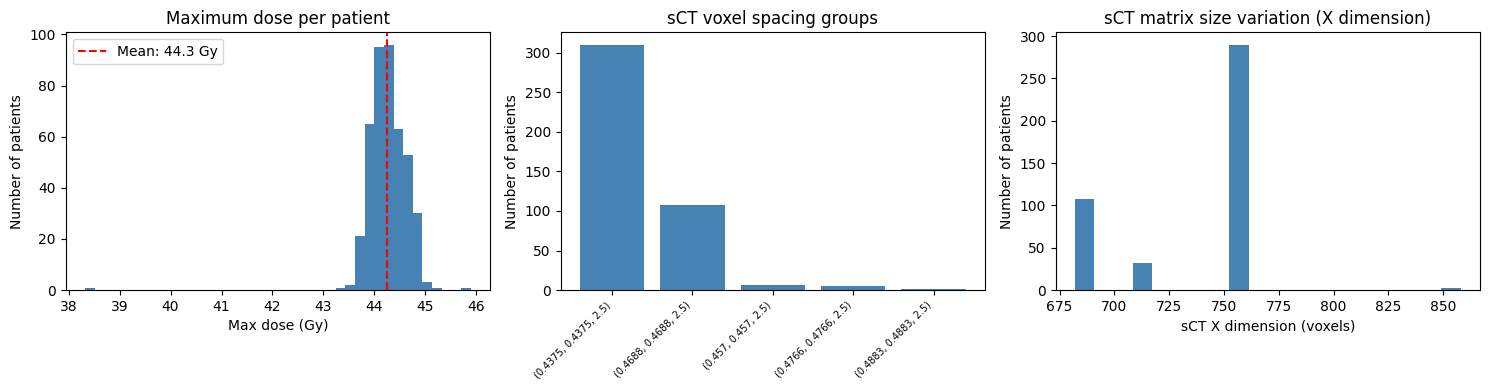

In [24]:
# Visualise the distribution of maximum dose across all 432 patients. 
# We also plot the distributions of CTV, PTV and Bladder volumes 
# to understand how much anatomical variability exists in the dataset.
# High variability in target volume size is clinically expected but
# means th emodel must generalise across a wide range of anatomy.

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Maximum dose distribution
axes[0].hist(df["doseMax (Gy) "], bins=40, color="steelblue", edgecolor="none")
axes[0].axvline(df["doseMax (Gy) "].mean(), color="red",
                linestyle="--", label=f'Mean: {df["doseMax (Gy) "].mean():.1f} Gy')
axes[0].set_xlabel("Max dose (Gy)")
axes[0].set_ylabel("Number of patients")
axes[0].set_title("Maximum dose per patient")
axes[0].legend()

# We need to parse structure volume columns from the metadata CSV.
# The column names with units are stripped for cleaner code below.
dose_col   = "doseMax (Gy) "

# Pull the max dose values and describe spread
print("Max dose summary across 432 patients:")
print(df[dose_col].describe().round(2))
print(f"\nPatients with max dose below 40 Gy: "
      f"{(df[dose_col] < 40).sum()} "
      f"({(df[dose_col] < 40).mean():.1%})")

# Plot sCT voxel spacing distribution to confirm the three groups we found earlier
spacing_counts = df["sCTVoxelSizeOrig (mm)"].value_counts()
axes[1].bar(range(len(spacing_counts)), spacing_counts.values, color="steelblue")
axes[1].set_xticks(range(len(spacing_counts)))
axes[1].set_xticklabels(
    [str(s) for s in spacing_counts.index],
    rotation=45, ha="right", fontsize=7
)
axes[1].set_ylabel("Number of patients")
axes[1].set_title("sCT voxel spacing groups")

# Plot distribution of sCT X dimension to show the three size groups
x_dims = df["sCTMatrixSizeOrig"].apply(
    lambda s: int(s.strip("()").split(",")[0])
)
axes[2].hist(x_dims, bins=20, color="steelblue", edgecolor="none")
axes[2].set_xlabel("sCT X dimension (voxels)")
axes[2].set_ylabel("Number of patients")
axes[2].set_title("sCT matrix size variation (X dimension)")

plt.tight_layout()
plt.show()

### Observations:
- Maximum dose per patient:
    - Bell-shaped around 44.25 Gy with very little spread, confirming prescription protocol is standardised across all patients.
    - Two outliers around 38 Gy, they received a lower maximum dose and should be inspected before training.

- sCT voxel spacing groups:
    - One dominant spacing (310 patients at 0.4375mm).
    - Resampling to that measure is reasonable since it containts 72% of the dataset.

- Size variation of X dimension:
    - Confirming 3 clusters at around 682, 715, and 756 voxels. 
    - 756 being the dominant one. 
    - outlier near 858

Reason why to to resample and padding to a fixed grid.

In [25]:
# Verify that the heavy right-skew in dose distribution is a consistent
# property across patients, not specific to the single patient we inspected.
# We use doseMax as a proxy — if max doses are consistent, the overall
# distribution shape is likely consistent too, since the prescription
# and delivery protocol is standardised across the cohort.

low_dose_patients = (df["doseMax (Gy) "] < 40).sum()
outlier_patients  = df[df["doseMax (Gy) "] < 40]["patient"].tolist()

print(f"Patients with max dose below 40 Gy: {low_dose_patients}")
print(f"Patient IDs: {outlier_patients}")
print(f"\nThese patients will be flagged for inspection before model training.")

# Summarise the three sCT size groups for the preprocessing decision
x_dims   = df["sCTMatrixSizeOrig"].apply(
    lambda s: int(s.strip("()").split(",")[0])
)
print(f"\nsCT X dimension groups:")
print(x_dims.value_counts().sort_index())

Patients with max dose below 40 Gy: 1
Patient IDs: ['oldAcq_5691db8853d0787c']

These patients will be flagged for inspection before model training.

sCT X dimension groups:
sCTMatrixSizeOrig
682    108
716     32
756    290
858      2
Name: count, dtype: int64


> Check what to do with Omar

### 3.5 Structure Analysis

Structure masks serve as both model inputs and evaluation references. This section documents which structures are present per patient, their volume distributions across 
the cohort, and the relationships between structure volumes. Understanding the range of target and OAR sizes matters because a model that only ever sees small 
prostates during training will struggle with large ones at test time, and it tells us whether the dataset covers the anatomical spectrum properly.

In [26]:
# Print all column names 
for col in df.columns:
    print(col)

patient
sCTMatrixSizeOrig
sCTVoxelSizeOrig (mm)
mriMatrixSize
mriVoxelSize (mm)
doseMatrixSizeOrig
doseVoxelSizeOrig
doseMin (Gy)
doseMax (Gy) 
acq_group
sct_x_dim


In [28]:
# Compute structure volumes for all 432 patients by loading their masks directly.
# All nine structures defined in LUND-PROBE are included: four primary OARs and
# target volumes (CTV, PTV, Bladder, Rectum), two femoral heads, two optional
# structures (PenileBulb and Genitalia, absent for some patients), and BODY.
# Volume = number of foreground voxels × voxel volume in cc.

from tqdm import tqdm

ALL_STRUCTURES = [
    ("CTV",          "mask_CTVT_427.nii.gz"),
    ("PTV",          "mask_PTVT_427.nii.gz"),
    ("Bladder",      "mask_Bladder.nii.gz"),
    ("Rectum",       "mask_Rectum.nii.gz"),
    ("FemoralHead_L","mask_FemoralHead_L.nii.gz"),
    ("FemoralHead_R","mask_FemoralHead_R.nii.gz"),
    ("PenileBulb",   "mask_PenileBulb.nii.gz"),
    ("Genitalia",    "mask_Genitalia.nii.gz"),
    ("BODY",         "mask_BODY.nii.gz"),
]

records = []

for patient in tqdm(patient_dirs, desc="Loading structure volumes"):
    sct_dir = patient / "sCT"

    # Voxel spacing from the sCT header — needed to convert voxel count to cc
    sct_img = nib.load(sct_dir / "image.nii.gz")
    voxel_vol_cc = np.prod(sct_img.header.get_zooms()) / 1000

    row = {"patient": patient.name}

    for structure, filename in ALL_STRUCTURES:
        mask_path = sct_dir / filename
        if mask_path.exists():
            mask = nib.load(mask_path).get_fdata()
            row[f"{structure}_cc"] = mask.sum() * voxel_vol_cc
        else:
            # NaN recorded for absent structures rather than crashing —
            # PenileBulb and Genitalia are known to be missing for some patients
            row[f"{structure}_cc"] = np.nan

    records.append(row)

volumes_df = pd.DataFrame(records)

print(f"Volume dataframe shape: {volumes_df.shape}")
print(f"\nMissing values per structure:")
print(volumes_df.isnull().sum())
print(f"\nSummary statistics (cc):")
print(volumes_df.drop(columns="patient").describe().round(1))

Loading structure volumes: 100%|██████████| 432/432 [38:14<00:00,  5.31s/it]

Volume dataframe shape: (432, 10)

Missing values per structure:
patient              0
CTV_cc               0
PTV_cc               0
Bladder_cc           0
Rectum_cc            0
FemoralHead_L_cc     0
FemoralHead_R_cc     0
PenileBulb_cc       29
Genitalia_cc        24
BODY_cc              0
dtype: int64

Summary statistics (cc):
       CTV_cc  PTV_cc  Bladder_cc  Rectum_cc  FemoralHead_L_cc  \
count   432.0   432.0       432.0      432.0             432.0   
mean     56.4   133.3       160.7       66.3              66.8   
std      22.3    38.9        97.9       23.8              10.1   
min      19.3    60.3        33.8       24.1              38.8   
25%      41.3   105.8        90.4       50.7              60.4   
50%      52.0   125.8       135.3       61.5              66.2   
75%      66.9   153.5       203.2       75.5              73.6   
max     164.6   313.8       573.3      197.5             106.4   

       FemoralHead_R_cc  PenileBulb_cc  Genitalia_cc  BODY_cc  
count  

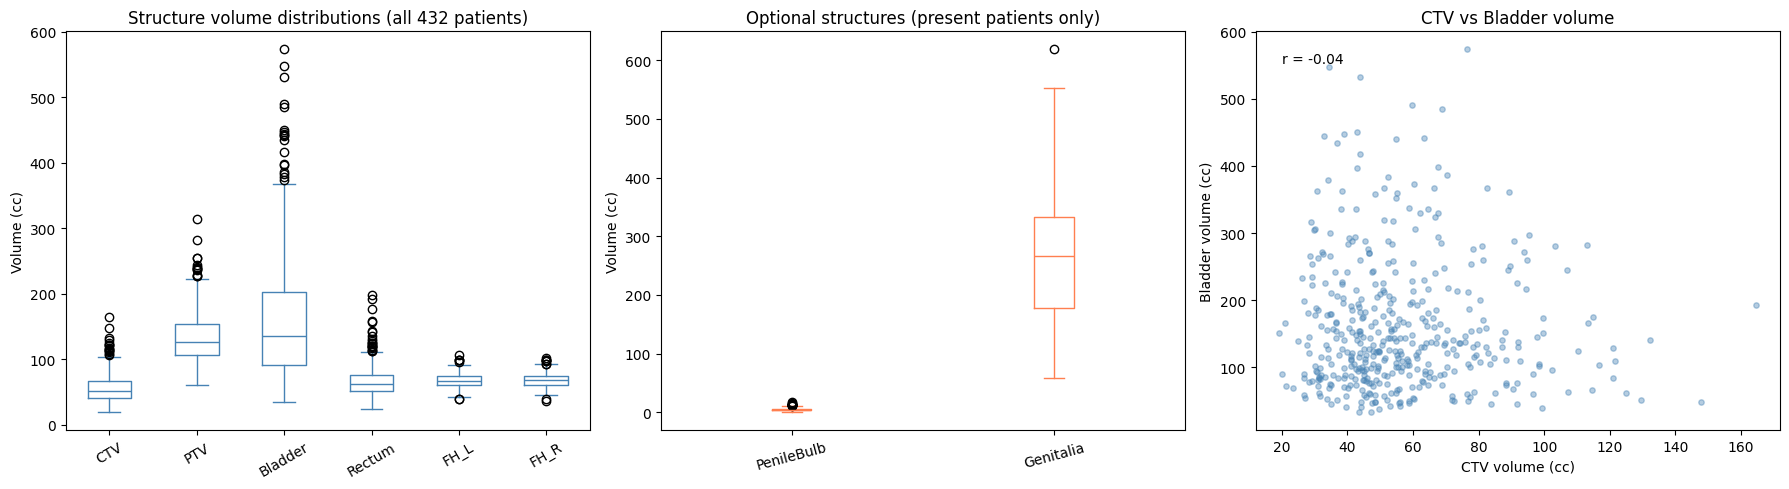

BODY contour volume summary (cc):
count      432.0
mean     15289.0
std       2372.0
min       9644.0
25%      13617.0
50%      14964.0
75%      16563.0
max      26995.0
Name: BODY_cc, dtype: float64


In [29]:
# Visualise volume distributions for the clinically meaningful structures.
# BODY is excluded from the box plot since its volume (~tens of thousands of cc)
# would compress all other structures into an unreadable range.
# Femoral heads are shown separately since they are bone structures with
# expected low variability compared to soft-tissue OARs.

clinical_structures = ["CTV_cc", "PTV_cc", "Bladder_cc", "Rectum_cc",
                       "FemoralHead_L_cc", "FemoralHead_R_cc"]
optional_structures  = ["PenileBulb_cc", "Genitalia_cc"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Box plots for the six primary structures
volumes_df[clinical_structures].plot.box(ax=axes[0], color="steelblue")
axes[0].set_ylabel("Volume (cc)")
axes[0].set_title("Structure volume distributions (all 432 patients)")
axes[0].set_xticklabels(
    ["CTV", "PTV", "Bladder", "Rectum", "FH_L", "FH_R"],
    rotation=30
)

# Box plots for optional structures (patients where present only)
volumes_df[optional_structures].dropna().plot.box(ax=axes[1], color="coral")
axes[1].set_ylabel("Volume (cc)")
axes[1].set_title("Optional structures (present patients only)")
axes[1].set_xticklabels(["PenileBulb", "Genitalia"], rotation=15)

# CTV vs Bladder scatter — unchanged from before
axes[2].scatter(volumes_df["CTV_cc"], volumes_df["Bladder_cc"],
                alpha=0.4, color="steelblue", s=15)
axes[2].set_xlabel("CTV volume (cc)")
axes[2].set_ylabel("Bladder volume (cc)")
axes[2].set_title("CTV vs Bladder volume")
corr = volumes_df["CTV_cc"].corr(volumes_df["Bladder_cc"])
axes[2].text(0.05, 0.92, f"r = {corr:.2f}",
             transform=axes[2].transAxes, fontsize=10)

plt.tight_layout()
plt.show()

# Report BODY volume separately since it represents the full patient outline
print("BODY contour volume summary (cc):")
print(volumes_df["BODY_cc"].describe().round(0))

### Notes/findings:
All nine structures definde in LUND-PROBE are present for the full 432 patient cohort, with the exeption of PenileBulb (missing for 29 patients) and Genitalia (missing for 24 patients), consistent with the dataset's missing structures JSON. No critical structures are absent for any patient.

Among the structures, bladder shows the most variability (std = 98cc, range 34–573cc), reflecting physiological differences in filling state at scan time. The femoral heads are the most consistent structures (std ≈ 10cc for both sides), as expected for rigid bone anatomy, and can serve as reliable spatial landmarks during model training. Genitalia shows a wide volume range (59–618cc) that likely reflects inconsistent contouring extent across the acquisition period rather than true anatomical variation, which warrants caution if this structure is included as a model input. The BODY contour (mean 15,290cc) represents the full patient outline and will be used to define the spatial extent of preprocessing normalisation rather than as a model input channel.

For the 29 patients missing PenileBulb and 24 missing Genitalia, the corresponding input channels will be filled with zeros during model training, a standard approach for optional structures in multi-channel volumetric dose prediction.

### 3.6 Baseline Reference

Before any deep learning model is trained, a naive baseline establishes the minimum performance floor that any learned model must exceed. For a voxel-wise dose regression task, the simplest possible baseline is a mean dose predictor: for every test patient, predict the mean dose volume of the training set rather than computing anything patient-specific. If a model cannot outperform this baseline, it has learned nothing useful about the anatomy-to-dose mapping. The baseline is computed here at the patient level using the maximum dose values available in the metadata CSV, since loading full 3D volumes for all patients is not necessary to establish 
this reference point.

In [37]:
# Naive baseline: predict the training set mean maximum dose for every patient.
# This is the simplest possible dose prediction strategy, it ignores all anatomy
# and simply outputs a constant. Any learned model must beat this to be useful.
# We use an 80/20 patient-level split, stratified by acquisition group to reflect
# the splitting strategy identified in the geometry analysis.

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# Stratified patient-level split — acquisition group as the stratification variable
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["acq_group"]
)

print(f"Train patients: {len(train_df)} "
      f"({train_df['acq_group'].value_counts().to_dict()})")
print(f"Test patients:  {len(test_df)} "
      f"({test_df['acq_group'].value_counts().to_dict()})")

# Baseline prediction: mean max dose across training patients
baseline_prediction = train_df["doseMax (Gy) "].mean()
print(f"\nBaseline prediction (train mean max dose): {baseline_prediction:.2f} Gy")

# Evaluate on test set
mae = mean_absolute_error(
    test_df["doseMax (Gy) "],
    [baseline_prediction] * len(test_df)
)
std_test = test_df["doseMax (Gy) "].std()

print(f"Baseline MAE on test set:  {mae:.3f} Gy")
print(f"Test set dose std:         {std_test:.3f} Gy")
print(f"\nAny learned model must achieve MAE < {mae:.3f} Gy to outperform "
      f"this baseline on maximum dose prediction.")

Train patients: 345 ({'oldAcq': 258, 'newAcq': 87})
Test patients:  87 ({'oldAcq': 65, 'newAcq': 22})

Baseline prediction (train mean max dose): 44.25 Gy
Baseline MAE on test set:  0.223 Gy
Test set dose std:         0.284 Gy

Any learned model must achieve MAE < 0.223 Gy to outperform this baseline on maximum dose prediction.


### Notes/observations:
The naive baseline, predicting the training set mean maximum dose of 44.25 Gy for every test patient,  achieves a mean absolute error of 0.223 Gy on the test set. This low error reflects the uniformity of the prescription protocol across the cohort rather than predictive power: the test set standard deviation of 0.284 Gy confirms that maximum dose varies little between patients, making it a poor discriminative target. The meaningful evaluation baseline for this thesis is a voxel-wise mean dose volume predictor, which will be computed during the model evaluation phase using the full 3D dose distributions. The current result establishes that the stratified patient-level split preserves proportional acquisition group representation across training (258 oldAcq, 87 newAcq) and 
test (65 oldAcq, 22 newAcq) sets, consistent with the 75/25 cohort split.

## Private Pancreatic Cohort Analysis (Amsterdam UMC) (PLACEHOLDER)

This section will characterise the private pancreatic MRgRT cohort from Amsterdam 
UMC following the same analytical structure applied to LUND-PROBE: dataset 
inventory, image geometry, intensity analysis, dose distribution, and structure 
analysis. Equivalent analyses enable direct comparison between the two cohorts in 
Section 5.

Initial inspection of the dataset reveals per-fraction MR volumes in NIfTI format 
across approximately 74 training and 27 evaluation patients. However, the dose 
distributions and structure segmentation masks have not yet been located in a 
processable format — the raw DICOM source data containing these files is available 
under a separate directory, but conversion to NIfTI or confirmation of the intended 
preprocessing pipeline is pending. Full analysis will be completed following 
clarification from the clinical supervisor (Omar Bohoudi) on three points: where 
the processed dose data resides, what structures are contoured and available, and 
what the out-of-distribution (OOD) subset represents.

The placeholders below define the analyses that will be conducted and the questions 
each is designed to answer.

In [30]:
# Current state of the private pancreatic cohort.
# This cell documents what has been confirmed through initial inspection
# and what remains to be verified with the clinical supervisor.

AUMC_PATH        = Path(r"\\vumc.nl\Onderzoek\s4e-gpfs2\rath-research-01\Research\Research_Kidney_AI_OB_ABR_MP_NGA_Joris\ZZZZZ-Thesis2026\Mattheus\AUMC")
TRAIN_NIFTI_PATH = AUMC_PATH / "Training-nifti"
EVAL_NIFTI_PATH  = AUMC_PATH / "Evaluation-nifti"

train_files = sorted(TRAIN_NIFTI_PATH.glob("*.nii.gz"))
eval_dirs   = sorted([d for d in EVAL_NIFTI_PATH.iterdir() if d.is_dir()])

# Extract unique patient IDs from training filenames (format: ID_ID-fraction.nii.gz)
train_patient_ids = sorted(set(f.name.split("_")[0] for f in train_files))

print(f"Training NIfTI files:       {len(train_files)}")
print(f"Unique training patients:   {len(train_patient_ids)}")
print(f"Evaluation patient folders: {len(eval_dirs)}")
print(f"\nExample training filename:  {train_files[0].name}")
print(f"Example evaluation folder:  {eval_dirs[0].name}")
print(f"\nConfirmed: each NIfTI file is a single 3D MR volume")
print(f"Confirmed: shape=(266, 266, 144), spacing=(1.50, 1.50, 3.0mm)")
print(f"\nPending confirmation:")
print(f"  - Location of processed dose distributions")
print(f"  - Location of structure segmentation masks")
print(f"  - Composition and purpose of the OOD subset")

Training NIfTI files:       442
Unique training patients:   74
Evaluation patient folders: 27

Example training filename:  001_001-0.nii.gz
Example evaluation folder:  086

Confirmed: each NIfTI file is a single 3D MR volume
Confirmed: shape=(266, 266, 144), spacing=(1.50, 1.50, 3.0mm)

Pending confirmation:
  - Location of processed dose distributions
  - Location of structure segmentation masks
  - Composition and purpose of the OOD subset


### 4.1 Dataset Inventory — Placeholder

To be completed. Will document total patient and fraction counts, confirm file 
completeness across all patients, and characterise the train/evaluation split. 
Will also clarify the purpose and composition of the OOD subset identified in the 
source directory.

### 4.2 Image Geometry — Placeholder

To be completed. Will characterise MR image dimensions and voxel spacing across 
all patients and fractions, and compare these against the LUND-PROBE sCT geometry. 
The preliminary inspection indicates a uniform shape of 266×266×144 at 1.5×1.5×3.0mm, 
but this needs to be verified across the full cohort.

### 4.3 Intensity Analysis — Placeholder

To be completed. Will characterise MR intensity distributions across patients and 
fractions. Particular attention will be paid to inter-fraction intensity variation 
for the same patient, since this directly reflects the day-to-day anatomical changes 
that motivate adaptive MRgRT and that the model must be robust to.

### 4.4 Dose Distribution and Structure Analysis — Placeholder

To be completed pending access to processed dose and structure data. Will mirror 
the LUND-PROBE analysis: dose histogram shape and skewness, maximum dose per 
patient, structure presence and volume distributions for the pancreatic OARs 
(duodenum, stomach, bowel, and others as available). Fraction-level dose variability 
will also be examined, as this is central to the robustness analysis in the thesis.

## Cross-Dataset Comparison — Placeholder

This section will directly compare LUND-PROBE and the Amsterdam UMC pancreatic 
cohort across the dimensions characterised in Sections 3 and 4. The comparison 
motivates the transfer learning component of the thesis: if the two datasets share 
enough geometric and dosimetric properties, a model pre-trained on LUND-PROBE may 
provide a useful initialisation for the pancreatic cohort. If they differ 
substantially, this informs how much fine-tuning will be needed and which aspects 
of the domain shift are most pronounced.

The following comparisons will be made once the pancreatic cohort analysis is 
complete.

**Image geometry**: voxel spacing, matrix dimensions, and slice thickness across 
both cohorts, to quantify the resampling required to bring both onto a common grid.

**Intensity distributions**: sCT Hounsfield unit ranges for LUND-PROBE versus MR 
intensity ranges for the pancreatic cohort. Since the two datasets use different 
input modalities (sCT versus MR), this comparison will focus on the normalisation 
strategies needed for each rather than direct intensity comparisons.

**Dose distribution properties**: maximum dose per patient, dose histogram shape, 
and fraction of voxels receiving therapeutic dose. Similarities here would suggest 
the models can share a common output normalisation strategy.

**Structure variability**: target volume size distributions and OAR volume ranges 
across both cohorts. Greater variability in the pancreatic cohort — expected given 
the mobile abdominal anatomy — would directly motivate the robustness analysis in 
Phase 3 of the experimental design.

**Dataset size and split considerations**: LUND-PROBE provides 432 patients for 
benchmarking, while the pancreatic cohort provides approximately 101 patients across 
a pre-defined train/evaluation split. This asymmetry affects how transfer learning 
experiments should be structured and what sample sizes are available for 
fine-tuning.

## EDA Findings

Data description.
all 432 patients are present with complete file structures. The sCT varies across patients, three dominant in-plane spacing groups (0.4375, 0.4688, 0.457mm) and X dimesnions clustering around 682, 716 an 756 voxels, while MR geometry is uniform at 1024x1024x88. Missing structures affect only 48 patients, limited to PenileBulb and Genetalia, with CTV and PTV complete for all patients. The dose distribution is heavily right-skewed with only around 0.6% of voxels receiving full therapeutic dose, and maximum dose is tightly standardised around 44.3 Gy across patients. One patient received a notably lower max dose and warrants inspection. Structure volumes show cllinically exepcted variability, with bladder being the most variable organ and CTV and bladder volumes being uncorrelated, ruling out systematic acqisition confounds.